# Исследование объявлений о продаже квартир

В вашем распоряжении данные сервиса Яндекс Недвижимость — архив объявлений о продаже квартир в Санкт-Петербурге и соседних населённых пунктах за несколько лет. Вам нужно научиться определять рыночную стоимость объектов недвижимости. Для этого проведите исследовательский анализ данных и установите параметры, влияющие на цену объектов. Это позволит построить автоматизированную систему: она отследит аномалии и мошенническую деятельность.

По каждой квартире на продажу доступны два вида данных. Первые вписаны пользователем, вторые — получены автоматически на основе картографических данных. Например, расстояние до центра, аэропорта и других объектов — эти данные автоматически получены из геосервисов. Количество парков и водоёмов также заполняется без участия пользователя.

### 1 Загрузка данных

In [1]:
import pandas as pd
data = pd.read_csv('/datasets/real_estate_data.csv', sep='\t')
data.info()
data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_images          23699 non-null  int64  
 1   last_price            23699 non-null  float64
 2   total_area            23699 non-null  float64
 3   first_day_exposition  23699 non-null  object 
 4   rooms                 23699 non-null  int64  
 5   ceiling_height        14504 non-null  float64
 6   floors_total          23613 non-null  float64
 7   living_area           21796 non-null  float64
 8   floor                 23699 non-null  int64  
 9   is_apartment          2775 non-null   object 
 10  studio                23699 non-null  bool   
 11  open_plan             23699 non-null  bool   
 12  kitchen_area          21421 non-null  float64
 13  balcony               12180 non-null  float64
 14  locality_name         23650 non-null  object 
 15  airports_nearest   

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.00,2019-03-07T00:00:00,3,2.70,16.0,51.0,8,NaN,...,25.00,NaN,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
1,7,3350000.0,40.40,2018-12-04T00:00:00,1,NaN,11.0,18.6,1,NaN,...,11.00,2.0,посёлок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0
2,10,5196000.0,56.00,2015-08-20T00:00:00,2,NaN,5.0,34.3,4,NaN,...,8.30,0.0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0
3,0,64900000.0,159.00,2015-07-24T00:00:00,3,NaN,14.0,NaN,9,NaN,...,NaN,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
4,2,10000000.0,100.00,2018-06-19T00:00:00,2,3.03,14.0,32.0,13,NaN,...,41.00,NaN,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23694,9,9700000.0,133.81,2017-03-21T00:00:00,3,3.70,5.0,73.3,3,NaN,...,13.83,NaN,Санкт-Петербург,24665.0,4232.0,1.0,796.0,3.0,381.0,NaN
23695,14,3100000.0,59.00,2018-01-15T00:00:00,3,NaN,5.0,38.0,4,NaN,...,8.50,NaN,Тосно,NaN,NaN,NaN,NaN,NaN,NaN,45.0
23696,18,2500000.0,56.70,2018-02-11T00:00:00,2,NaN,3.0,29.7,1,NaN,...,NaN,NaN,село Рождествено,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23697,13,11475000.0,76.75,2017-03-28T00:00:00,2,3.00,17.0,NaN,12,NaN,...,23.30,2.0,Санкт-Петербург,39140.0,10364.0,2.0,173.0,3.0,196.0,602.0


array([[<AxesSubplot:title={'center':'total_images'}>,
        <AxesSubplot:title={'center':'last_price'}>,
        <AxesSubplot:title={'center':'total_area'}>,
        <AxesSubplot:title={'center':'rooms'}>],
       [<AxesSubplot:title={'center':'ceiling_height'}>,
        <AxesSubplot:title={'center':'floors_total'}>,
        <AxesSubplot:title={'center':'living_area'}>,
        <AxesSubplot:title={'center':'floor'}>],
       [<AxesSubplot:title={'center':'kitchen_area'}>,
        <AxesSubplot:title={'center':'balcony'}>,
        <AxesSubplot:title={'center':'airports_nearest'}>,
        <AxesSubplot:title={'center':'cityCenters_nearest'}>],
       [<AxesSubplot:title={'center':'parks_around3000'}>,
        <AxesSubplot:title={'center':'parks_nearest'}>,
        <AxesSubplot:title={'center':'ponds_around3000'}>,
        <AxesSubplot:title={'center':'ponds_nearest'}>],
       [<AxesSubplot:title={'center':'days_exposition'}>, <AxesSubplot:>,
        <AxesSubplot:>, <AxesSubplot:>]], d

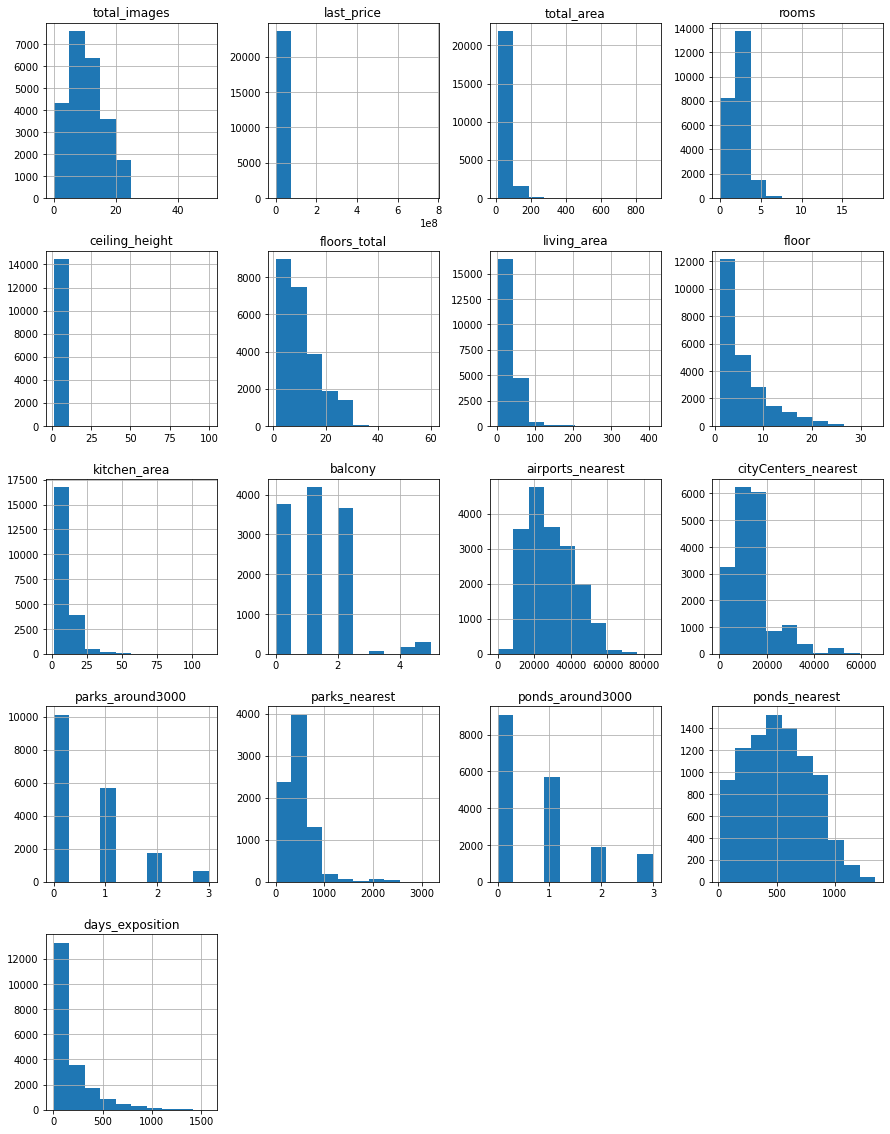

In [2]:
data.hist(figsize=(15,20))

В данных можно увидеть следующие проблемы:

- пропуски (в основном пропуски в данных, заполняемых автоматически на основе данных с карт)
- некорректный тип данных (дата публикации объявления с типом object, количество балконов/парков/водоемов с типом float)

Судя по гистограммам у большинства данных нормальное распределение, есть лишь некоторые выбросы (аномальные значения)

### 2 Предобработка данных

In [3]:
data.drop_duplicates() # удаление явных дубликатов
data['balcony'] = data['balcony'].fillna(0) # замена пропущенного число балконов на 0
data['is_apartment'] = data['is_apartment'].fillna(False) # замена пропущенных значений на False
data = data.dropna(subset=['locality_name'])# удаление строк с пропусками в locality_name
data = data.dropna(subset=['floors_total'])# удаление строк с пропусками в floors_total
data['parks_around3000'] = data['parks_around3000'].fillna(0) # заполнение пропусков на значение 0 
data['ponds_around3000'] = data['ponds_around3000'].fillna(0) # заполнение пропусков на значение 0 
data['ceiling_height'] = data['ceiling_height'].fillna(value=data['ceiling_height'].median())
s_living = data['living_area'] / data['total_area'] # отношение жилой площади к общей площади
data['living_area'] = data['living_area'].fillna(value = s_living.mean() * data['total_area'])
s_kitchen = data['kitchen_area'] / data['total_area'] # отношение площади кухни к общей площади
data['kitchen_area'] = data['kitchen_area'].fillna(value= s_kitchen.mean() * data['total_area'])
data.isna().sum()

total_images                0
last_price                  0
total_area                  0
first_day_exposition        0
rooms                       0
ceiling_height              0
floors_total                0
living_area                 0
floor                       0
is_apartment                0
studio                      0
open_plan                   0
kitchen_area                0
balcony                     0
locality_name               0
airports_nearest         5524
cityCenters_nearest      5501
parks_around3000            0
parks_nearest           15535
ponds_around3000            0
ponds_nearest           14529
days_exposition          3171
dtype: int64

In [4]:
new_locality = ['поселок ', 'деревня ', 'городской ', 'городского типа ', 'садовое товарищество ', 'станции ', 
                'коттетжный ', 'село ', 'садоводческое некоммерческое товарищество ', 'при железнодорожной ', 'коттеджный ', 'посёлок ']
for row in data['locality_name']:
    for locality in new_locality:
        if locality in row:
            data['locality_name'] = data['locality_name'].str.replace(locality, '')
data['locality_name'].unique()

array(['Санкт-Петербург', 'Шушары', 'Янино-1', 'Парголово', 'Мурино',
       'Ломоносов', 'Сертолово', 'Петергоф', 'Пушкин', 'Кудрово',
       'Коммунар', 'Колпино', 'Красный Бор', 'Гатчина', 'Фёдоровское',
       'Выборг', 'Кронштадт', 'Кировск', 'Новое Девяткино',
       'Металлострой', 'Лебяжье', 'Сиверский', 'Молодцово',
       'Кузьмоловский', 'Новая Ропша', 'Павловск', 'Пикколово',
       'Всеволожск', 'Волхов', 'Кингисепп', 'Приозерск', 'Сестрорецк',
       'Куттузи', 'Аннино', 'Ефимовский', 'Плодовое', 'Заклинье',
       'Торковичи', 'Первомайское', 'Красное Село', 'Понтонный',
       'Сясьстрой', 'Старая', 'Лесколово', 'Новый Свет', 'Сланцы',
       'Путилово', 'Ивангород', 'Шлиссельбург', 'Никольское',
       'Зеленогорск', 'Сосновый Бор', 'Оржицы', 'Кальтино', 'Романовка',
       'Бугры', 'Рощино', 'Кириши', 'Луга', 'Волосово', 'Отрадное',
       'Павлово', 'Оредеж', 'Копорье', 'Молодёжное', 'Тихвин', 'Победа',
       'Нурма', 'Синявино', 'Тосно', 'Стрельна', 'Бокситогорск',

Обнаружены пропущенные значения в следующих столбцах:
- высота потолков (пропущенные значения заполнены медианным для столбца значением)
- общее число этажей в доме (удалено, 85 данных не влияют на общую выборку, но затрудняют обработку остальных столбцов - тип этажа)
- жилая площадь (пропущенные значения заполнены исходя из зависимости от общей площади)
- апартаменты (пропущенные значения изменены на False, тк большинство квартир, как правило, не являются апартаментами, пропуски могли возникнуть из-за того, что некоторые пользователи не знают, что такое апартаменты и пропускают этот пункт при заполнении анкеты)
- площадь кухни (пропущенные значения заполнены исходя из зависимости от общей площади)
- количество балконов (заменено на 0. Возможно, пользователи пропускали этот пункт, так как балкона в квартире нет)
- название населенного пункта (удалено, 49 данных не влияют на общую выборку, но затрудняют обработку остальных столбцов)
- расстояние до ближайшего аэропорта (пропущенные значения оставлены, так как недостаточно информации для их заполнения)
- расстояние до центра города (пропущенные значения оставлены, так как недостаточно информации для их заполнения)
- число водоемов в радиусе 3 км (удалено, скорее всего пропуск означает, что водоемов в радиусе 3000м нет)
- расстояние до ближайшего водоема 
- число парков в радиусе 3 км (удалено, скорее всего пропуск означает, что парков в радиусе 3000м нет)
- расстояние до ближайшего парка (пропущенные значения оставлены, так как недостаточно информации для их заполнения)
- сколько дней было размещено объявление (пропущенные значения оставлены, так как недостаточно информации для их заполнения)

In [5]:
data['first_day_exposition'] = pd.to_datetime(data['first_day_exposition'], format='%Y-%m-%dT%H:%M:%S')
data['is_apartment'] = data['is_apartment'].astype('bool')
data['floors_total'] = round(data['floors_total'].astype('int'))
data['parks_around3000'] = round(data['parks_around3000'].astype('int'))
data['ponds_around3000'] = round(data['ponds_around3000'].astype('int'))
data['last_price'] = round(data['last_price'].astype('int'))
data['balcony'] = round(data['balcony'].astype('int'))

Изменение типов данных было произведено в следующих столбцах:
- "дата публикации" (тип данных float изменен на datetime, это необходимо для дальнейшей работы с этими датами (довабление столбцов с днем недели/месяцем/годом публикации))
- "апартаменты или нет" (тип данных object изменен на bool, так как в столбце указаны значения соответствущие типу данных bool)
- "общее число этажей" (тип данных float изменен на int, число этажей не может быть дробным ни как каких случаях, поэтому целесообразно изменение типа данных на int с отбрасыванием дробной части)
- "число парков/водоемов в радиусе 3000м (тип данных float изменен на int, число парков/водоемов не может быть дробным ни как каких случаях, поэтому целесообразно изменение типа данных на int с отбрасыванием дробной части)
- "количество водоемов" (тип данных float изменен на int, количество балконов не может быть дробным ни как каких случаях, поэтому целесообразно изменение типа данных на int с отбрасыванием дробной части)
- "цена на момент снятия публикации" (тип данных float изменен на int, так как в дробной части цены 0, поэтому их можно отбросить для более удобных дальнейших расчетов)

### 3 Добавление в таблицу новых столбцов

In [6]:
data['metr_price'] = round((data['last_price'] / data['total_area']), 2) 
data['weekday_exposition'] = data['first_day_exposition'].dt.weekday 
data['month_exposition'] = data['first_day_exposition'].dt.month
data['year_exposition'] = data['first_day_exposition'].dt.year
def categorize_floor(row):
    try:
        if row['floor'] == 1:
            return 'первый'
        elif row['floor'] == row['floors_total']:
            return 'последний'
        else:
            return 'другой'
    except:
        pass
data['floor_type'] = data.apply(categorize_floor, axis=1)   
data['cityCenters_nearest_km'] = round(data['cityCenters_nearest'] / 1000)
data

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,metr_price,weekday_exposition,month_exposition,year_exposition,floor_type,cityCenters_nearest_km
0,20,13000000,108.00,2019-03-07,3,2.70,16,51.000000,8,False,...,482.0,2,755.0,NaN,120370.37,3,3,2019,другой,16.0
1,7,3350000,40.40,2018-12-04,1,2.65,11,18.600000,1,False,...,NaN,0,NaN,81.0,82920.79,1,12,2018,первый,19.0
2,10,5196000,56.00,2015-08-20,2,2.65,5,34.300000,4,False,...,90.0,2,574.0,558.0,92785.71,3,8,2015,другой,14.0
3,0,64900000,159.00,2015-07-24,3,2.65,14,89.825011,9,False,...,84.0,3,234.0,424.0,408176.10,4,7,2015,другой,7.0
4,2,10000000,100.00,2018-06-19,2,3.03,14,32.000000,13,False,...,112.0,1,48.0,121.0,100000.00,1,6,2018,другой,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23694,9,9700000,133.81,2017-03-21,3,3.70,5,73.300000,3,False,...,796.0,3,381.0,NaN,72490.85,1,3,2017,другой,4.0
23695,14,3100000,59.00,2018-01-15,3,2.65,5,38.000000,4,False,...,NaN,0,NaN,45.0,52542.37,0,1,2018,другой,NaN
23696,18,2500000,56.70,2018-02-11,2,2.65,3,29.700000,1,False,...,NaN,0,NaN,NaN,44091.71,6,2,2018,первый,NaN
23697,13,11475000,76.75,2017-03-28,2,3.00,17,43.358928,12,False,...,173.0,3,196.0,602.0,149511.40,1,3,2017,другой,10.0


### 4 Исследовательский анализ данных

<AxesSubplot:title={'center':'площадь кухни'}, ylabel='Frequency'>

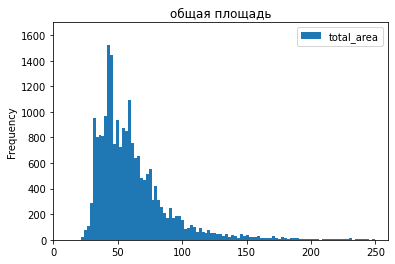

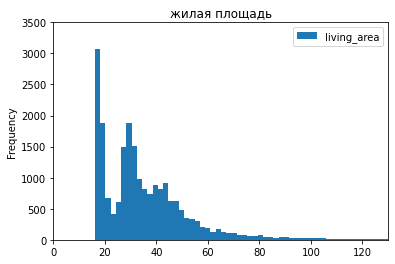

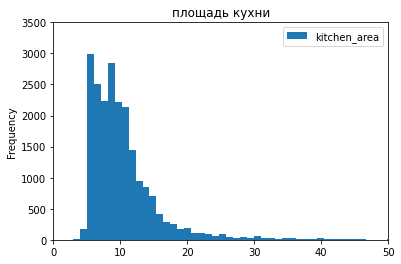

In [7]:
# обработка аномальных значений общей площади
good_data = data.query('20 < total_area < 250')
# обработка аномальных значений жилой площади
good_data = good_data.query('living_area > 16')
# обработка аномальных значений площади кухни
good_data = good_data.query('kitchen_area > 2')
good_data.plot(y='total_area', bins=100, kind='hist', xlim=(0,260), ylim=(0,1700), title='общая площадь')
good_data.plot(y='living_area', bins=100, kind='hist', xlim=(0,130), ylim=(0,3500), title='жилая площадь')
good_data.plot(y='kitchen_area', bins=100, kind='hist', xlim=(0,50), ylim=(0,3500), title='площадь кухни')

- Отброшены некоторые значения площадей квартир (оставлены только те, что больше 20 м^2 и меньше 250м^2, так как остальные помещения возможно не являются квартирами в принципе и их незначительное количество, их наличие может искажать результат исследования)
- Отброшены некоторые значения жилых площадей (меньше 18 м^2, такие значения являются аномальными и могут исказить результат исследования)
- Отброшены некоторые значения площадей кухни (меньше 2 м^2, такие значения являются аномальными)

/opt/conda/lib/python3.9/site-packages/pandas/core/indexing.py:1676: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(ilocs[0], value, pi)


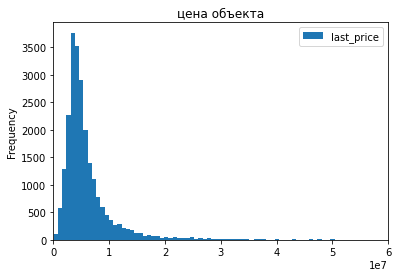

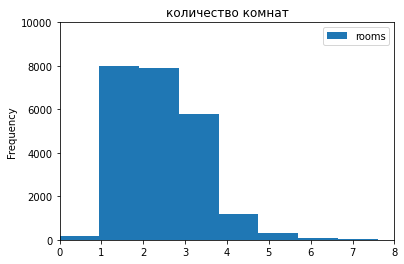

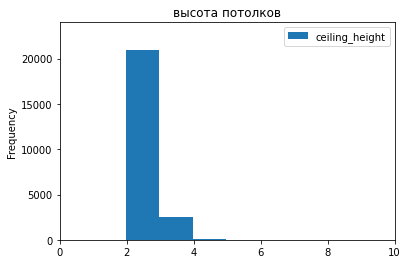

In [8]:
data.plot(y='last_price', bins=1000, kind='hist', xlim=(0,60000000), title='цена объекта')
data.plot(y='rooms', bins=20, kind='hist', xlim=(0,8), ylim=(0,10000), title='количество комнат')
data.plot(y='ceiling_height', bins=100, kind='hist', xlim=(0,10), ylim=(0,24000), title='высота потолков')
# обработка аномальных значений высоты потолков
good_data = good_data.query('2.5 < ceiling_height < 100')
good_data.loc[good_data['ceiling_height'] > 20, 'ceiling_height'] = good_data.loc[good_data['ceiling_height'] > 20, 'ceiling_height'] / 10
good_data = good_data.query('ceiling_height < 4')
# обработка аномальных значений количества комнат
good_data = good_data.query('rooms > 0')
# обработка аномальных значений цены объекта
good_data = good_data.query('last_price > 1000000')

- Отброшены некоторые значения высоты потолков: меньше 2,5м (так как по документации высота потолков не должна быть меньше 2,5м) и больше 4 м. Также некоторые аномальные значения (от 20м до 40м были заменены на значения от 2м до 4м соответственно, так как пользователь скорее всего подразумевал эти значения высоты потолков, но ошибся при заполнении анкеты)
- Отброшены аномальные значения количества комнат (0 комнат)
- Отброшены аномальные цены объектов (те, что меньше 1,5 млн)

<AxesSubplot:title={'center':'тип этажа квартиры'}>

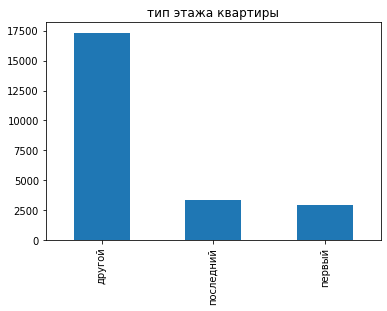

In [9]:
data['floor_type'].value_counts().plot(kind='bar', title='тип этажа квартиры')

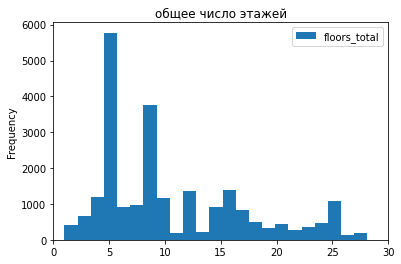

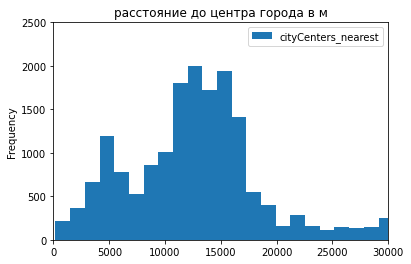

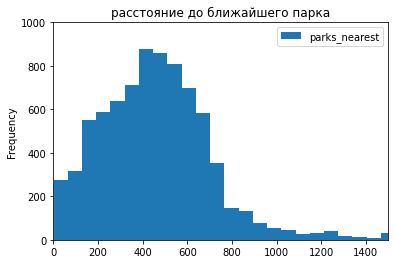

In [10]:
data.plot(y='floors_total', bins=50, kind='hist', xlim=(0,30), title='общее число этажей')
data.plot(y='cityCenters_nearest', bins=50, kind='hist', xlim=(0,30000), ylim=(0,2500), title='расстояние до центра города в м')
data.plot(y='parks_nearest', bins=50, kind='hist', xlim=(0,1500), ylim=(0,1000), title='расстояние до ближайшего парка')
# обработка аномальных значений общего числа этажей
good_data = good_data.query('1 < floors_total < 30')

- Отброшены некоторые выбивающиеся значения в общем количестве этажей ( 1 этаж и больше, чем 30 этажей)

AxesSubplot(0.125,0.125;0.775x0.755)
Среднее значение: 180.7413945278023
Медиана: 95.0


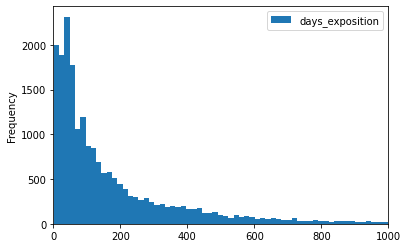

In [11]:
# анализ столбца "days_exposition"
print(data.plot(y='days_exposition', kind='hist', bins=100, xlim=(0,1000)))
print('Среднее значение:', data['days_exposition'].mean())
print('Медиана:', data['days_exposition'].median())

Можно заметить, что обычно продажа занимает от 80 до 100 суток. Вывод сделан исходя из медианного значения, так как оно менее подвержено выбросам. Быстрыми считаются продажи до 50 суток, судя по гистограмме таких продаж было достаточно много. Необычно долгие продажи - от 500 суток, по гистограмме видно, что таких продаж немного, при этом при увеличении количества дней продаж становится меньше.

,total_images,last_price,total_area,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,...,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,metr_price,weekday_exposition,month_exposition,year_exposition,cityCenters_nearest_km
total_images,1.000000,0.121054,0.112237,0.082302,0.047551,0.014750,0.092253,0.034927,0.005217,-0.013304,...,0.027355,-0.009519,0.000478,0.005825,-0.035218,0.133690,-0.009875,0.006506,0.150075,-0.042035
last_price,0.121054,1.000000,0.660585,0.388285,0.326616,-0.005999,0.572427,0.024218,0.030380,-0.008736,...,0.263336,-0.013921,0.253093,-0.118579,0.107815,0.816234,-0.015742,0.003827,-0.034007,-0.272000
total_area,0.112237,0.660585,1.000000,0.786808,0.389950,-0.070872,0.934179,-0.027688,0.021814,-0.021032,...,0.213539,-0.017737,0.204625,-0.099220,0.171013,0.288113,-0.022416,0.008991,-0.075778,-0.254265
rooms,0.082302,0.388285,0.786808,1.000000,0.260409,-0.215461,0.855463,-0.146192,-0.000189,-0.021248,...,0.155781,-0.061666,0.113123,-0.061536,0.128740,0.040301,-0.014180,0.002910,-0.054712,-0.198725
ceiling_height,0.047551,0.326616,0.389950,0.260409,1.000000,-0.172210,0.374477,-0.104001,0.047724,0.000298,...,0.272957,-0.075269,0.207512,-0.120385,0.115611,0.272746,-0.039389,-0.013650,-0.003009,-0.306727
floors_total,0.014750,-0.005999,-0.070872,-0.215461,-0.172210,1.000000,-0.162967,0.670733,-0.036266,0.019116,...,-0.176907,0.097148,-0.084278,0.085866,-0.061165,0.121873,0.013987,0.009471,0.034018,0.047066
living_area,0.092253,0.572427,0.934179,0.855463,0.374477,-0.162967,1.000000,-0.096139,0.020213,-0.014057,...,0.216945,-0.051802,0.183229,-0.085552,0.160628,0.200180,-0.021415,0.004602,-0.071430,-0.249044
floor,0.034927,0.024218,-0.027688,-0.146192,-0.104001,0.670733,-0.096139,1.000000,-0.019644,0.008409,...,-0.116746,0.079027,-0.050003,0.063373,-0.047329,0.111171,0.017814,0.016103,0.027015,0.026670
is_apartment,0.005217,0.030380,0.021814,-0.000189,0.047724,-0.036266,0.020213,-0.019644,1.000000,-0.000871,...,0.024142,-0.032818,0.027548,0.008164,0.002943,0.038866,-0.012001,0.000086,0.019498,0.009496
studio,-0.013304,-0.008736,-0.021032,-0.021248,0.000298,0.019116,-0.014057,0.008409,-0.000871,1.000000,...,-0.004065,-0.005879,0.000487,-0.001565,-0.012334,0.003058,-0.012947,-0.007427,-0.023022,0.000314


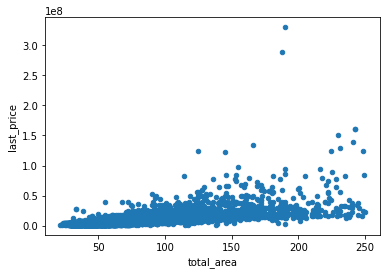

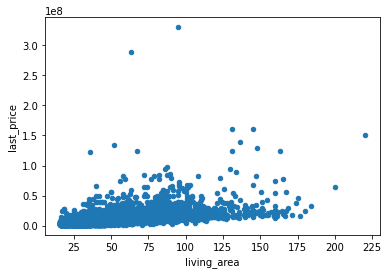

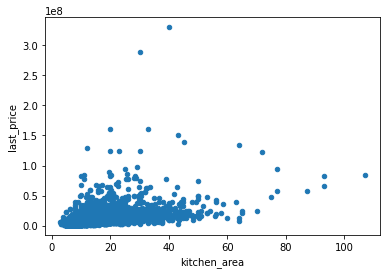

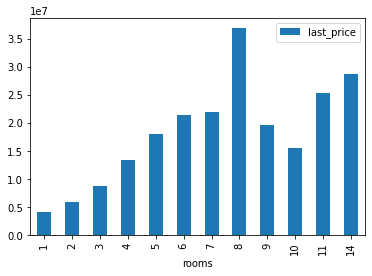

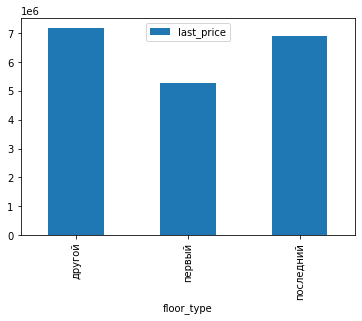

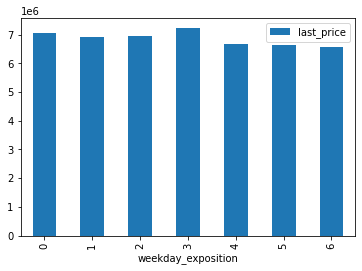

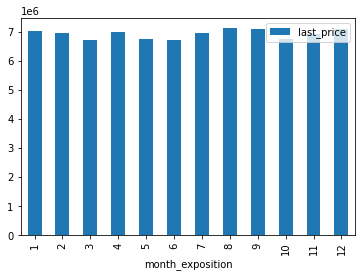

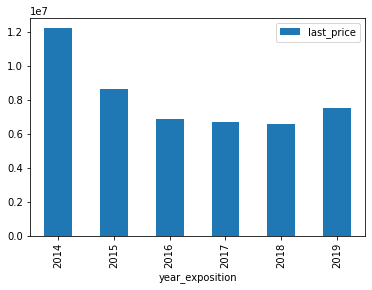

In [12]:
# определение факторов, влияющих на полную стоимость объекта
good_data.plot(x='total_area', y='last_price', kind='scatter')
good_data.plot(x='living_area', y='last_price', kind='scatter')
good_data.plot(x='kitchen_area', y='last_price', kind='scatter')
rooms_table = good_data.pivot_table(index='rooms', values='last_price')
rooms_table.plot(kind='bar')
floor_table = good_data.pivot_table(index='floor_type', values='last_price')
floor_table.plot(kind='bar')
weekday_table = good_data.pivot_table(index='weekday_exposition', values='last_price')
weekday_table.plot(kind='bar')
month_table = good_data.pivot_table(index='month_exposition', values='last_price')
month_table.plot(kind='bar')
year_table = good_data.pivot_table(index='year_exposition', values='last_price')
year_table.plot(kind='bar')
good_data.corr()

Исходя из построенных диаграмм рассеяния и таблицы с коэффициентами корреляции можно сделать вывод, что из количественных переменных больше всего итоговая цена объекта зависит от общей площади (коэффициент корреляции примерно 0,6), также есть зависимость от жилой площади и площади кухни, но они меньше.
Исходя из категориальных переменных тоже можно рассмотреть несколько зависимостей:
- дороже всех продавались 8-комнатные квартиры (средняя цена сильно отличается от других цен), дешевле всех 1-, 2-, 3-комнатные, а также относительно недорого стоят 10-комнатные квартиры 
- дороже всех продавались квартиры на "другом" этаже (не на первом или последнем), примерно по той же цене продавались квартиры на последнем этаже, дешевле всех - на первом
- дороже всех продавались квартиры, опубликованные в четверг, дешевле всех в выходные (субботу/воскресенье). Возможно, это связано с тем, что покупатели предпочитают решать важные вопросы, связанные с покупкой недвижимости, в будние дни, нежели в выходные.
- дороже всех продавались квартиры, опубликованные зимой, возможно, это связано с тем, что недвижимость покупается в качестве подарка или же покупается после получения ежегодной премии. дешевле всех продавались квартиры, опубликованные в конце весны и летом, скорее всего это связано с тем, что это время потенциальные покупатели в отпусках и их временно не интересует покупка дорогостоящей квартиры 
- дороже всех продавались квартиры, опубликованные в 2014 году, дешевле всех - в 2018 (возможно, это связано с тем, что в 2014 году сервис был одним из немногих известных на рынке, поэтому пользовался популярностью)

In [13]:
# средняя цена 1 м^2 в 10 населенных пунктов с наибольшим числом объявлений
sorted_data = data['locality_name'].value_counts().head(10)
sorted_data_and_price = data.query('locality_name in @sorted_data.index')
sorted_data_and_price.pivot_table(index='locality_name', values='metr_price').sort_values(by='metr_price', ascending=False)

,metr_price
locality_name,
Санкт-Петербург,114868.877339
Пушкин,103125.819377
Кудрово,95260.846128
Парголово,90175.913089
Мурино,86041.116024
Шушары,78551.344647
Колпино,75424.579112
Гатчина,68746.146515
Всеволожск,68654.473970


Самая высокая стоимость квадратного метра в Санкт-Петербурге - 114868руб/м^2(город федерального значения), самая низкая - в Выборге - 58141руб/м^2

,last_price
cityCenters_nearest_km,
0.0,3.144912e+07
1.0,2.120672e+07
2.0,1.778832e+07
3.0,1.113739e+07
4.0,1.330428e+07
5.0,1.445600e+07
6.0,1.533842e+07
7.0,1.477515e+07
8.0,9.949111e+06


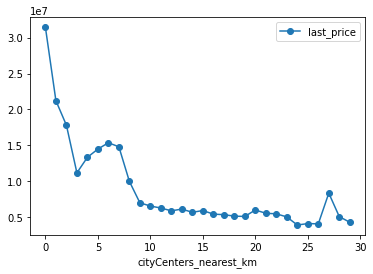

In [14]:
# средняя стоимость квартир на разном удалении от центра Санкт-Петербурга
data_spb = data.query('locality_name == "Санкт-Петербург"')
data_spb['cityCenters_nearest_km'].value_counts()
data_spb = data_spb.pivot_table(index='cityCenters_nearest_km', values='last_price')
data_spb.plot(kind='line', style='o-')
data_spb

Исходя из таблицы и графика можно заметить, что при уменьшении расстояния до центра города стоимость объекта увеличивается, то есть квартиры, расположенные непосредственно в центре Санкт-Петербурга стоят дороже, чем квартиры удаленные от центра на некоторое расстояние. После 10 км от центра города происходит резкое уменьшение стоимости объекта по сравнению с теми, что удалены от центра менее чем на 10 км.

### 5 Общий вывод

В качестве исходных данных была передана таблица с информацией о продажах объектов недвижимости в Санкт-Петербурге и ближайших населенных пунктах за несколько лет.

1) При предобработке данных были замечены следующие проблемы:

- Пропущенные значения

Большинство пропущенных значений было в столбцах, заполняемых автоматически на основе информации с карт (расстояние до центра города, количество ближайших водоемов/парков и т.д.). Также были пропущенные значения в данных, заполняемых пользователями самостоятельно (количество балконов, высота потолков, площадь жилой зоны, площадь кухни). Такие данные были либо оставлены (если недостаточно информации для их заполнения), либо изменены на нулевое значение (например, количество балконов). Несколько строчек, содержащих пропуски в столбцах "название населенного пункта" (49 строчек с пропусками в этом столбце)/"общее число этажей" (85 строчек с пропусками в этом столбце) были удалены из общей выборки, так как такие данные не влияют на результаты исследования, но затрудняют их дальнейшую обработку.

- Неверный тип данных

Изменен тип данных в следующих столбцах: "дата публикации объявления" (тип данных object на datetime), "апартаменты или нет" (тип данных object заменен на bool, так как значения в этом столбце соответствуют именно этому типу данных), "количество парков/водоемов в радиусе 3000м"/ "цена на момент снятия публикации"/"количество балконов" (тип данных float был заменен на int, так как эти значения не могут быть дробными, поэтому для более удобной дальнейшей обработке был изменен тип данных и отброшена дробная часть)

- Неявные дубликаты

Были обработаны неявные дубликаты в данных. Удалены типы населенных пунктов (поселок, деревня и тд)

- Аномальные значения

Были удалены некоторые аномальные значения: одноэтажные дома (в столбце "общее число этажей"), неправдоподобно низкие цены на объекты - меньше 1 млн (в столбце "цена на момент снятия с публикации"), объекты с слишком маленькой или слишком большой площадью (в столбце "общая площадь") и другие.

2) Дополнительно созданы следующие столбцы:

- цена одного квадратного метра;
- день публикации объявления (0 - понедельник, 1 - вторник и т. д.);
- месяц публикации объявления;
- год публикации объявления;
- тип этажа квартиры (значения — «первый», «последний», «другой»);
- расстояние до центра города в километрах.

Они необходимы для дальнейшего анализа зависимостей.

3) В результате исследования данных были найдены следующие зависимости:

- в среднем продажа объекта занимает от 80 до 100 суток. Быстрыми считаются продажи до 50 суток, долгими - от 500 суток
- итоговая цена объекта больше всего зависит от общей площади (коэффициент корреляции примерно 0,6), также цена объекта зависит от жилой площади и площади кухни. 
- дороже всех продавались 8-комнатные квартиры, дешевле всех одно-, двух-комнатные и т.д.
- дороже всех продавались квартиры, расположенные не на первом и не на последнем этажах, дешевле всех те, что расположены на первых этажах 
- более дорогостоящие сделки покупатели совершались на квартиры, опубликованные зимой, возможно это связано с государственными праздниками или получением годовой премии, дешевле всех продавались квартиры, опубликованные в конце весны и в летние месяцы
- дороже всех продавались квартиры, опубликованные в 2014 году, дешевле всех в 2018(возможно, это связано с тем, что в 2014 году сервис был одним из немногих известных на рынке, поэтому пользовался популярностью) 
- выделены населенные пункты с самой высокой ценой за м^2 (Санкт-Петербург) и самой низкой (Выборг)
- найдены средние цена на объекты при различном удалении от центра Санкт-Петербурга (информация поможет отслеживать аномально низкие цены на недвижимость)

4) Рекомендации

- желательно проверить работу автоматического добавления информации от карт (расстояние до центра города, количество ближайших парков/водоемов), так как очень часто встречаются пропуски именно в этих данных
- решить проблему в пропусках в столбцах об апартаментности, высоте потолков, жилой площади, площади кухни. Отсутствие пропусков в этих данных может увеличить продажи.
- решить проблемы аномально низких цен на основе средних цен объектов недвижимости на различных расстояниях от центра города
- стоит изучить зависимость количества балконов от цены на момент снятия публикации (как показывает практика, количество балконов - немаловажный показатель)
- стоит изучить зависимость типа недвижимости (апартаменты или нет) от итоговой стоимости квартиры (чаще всего потенциальные покупатели относятся к апартаментам с недоверием, поэтому такой тип недвижимости покупается реже). Аналагично со столбцом с информацией о том, студия или нет
- стоит изучить зависимость числа фотографий от итоговой стоимости квартиры (возможно, дороже продаются квартиры с бОльшим числом фотографий)